# Gemma-3 Benchmark Analysis

This notebook benchmarks the performance of various `google/gemma-3` models in generating semantic channel descriptions. It compares the description-induced channel topology against the ground truth point cloud topology derived from 20D video-title embeddings.

## 1) Setup & Dependencies
Install requirements, mount Google Drive, and import necessary libraries.

In [1]:
!pip install -q pandas numpy scipy sentence-transformers matplotlib seaborn

import os
import json
import time
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import pearsonr, spearmanr, kendalltau
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer

try:
    from google.colab import ai
except ImportError:
    pass

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    print('Not running in Colab. Falling back to local execution.')
    IN_COLAB = False

sns.set_theme(style='whitegrid', context='notebook')

Mounted at /content/drive


## 2) Configuration
Define target models, data paths, and output locations.

In [31]:
MODELS = [
    'gemma-4-31b-it',
    'gemma-4-26b-a4b-it',
    'gemini-3-flash-preview',
    'gemini-3.1-flash-lite'
]

DRIVE_ROOT = Path('/content/drive/MyDrive')
GRAPHIKO_ROOT = DRIVE_ROOT / 'Graphiko'

VIDEO_EMBEDDINGS_CSV = (
    GRAPHIKO_ROOT
    / 'exports/video_embeddings_reduced/latest/business_cluster_video_embeddings_reduced_20d.csv'
)

BENCHMARK_OUTPUT_DIR = GRAPHIKO_ROOT / 'research/benchmark/latest'
BENCHMARK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CACHED_DESCRIPTIONS_PATH = BENCHMARK_OUTPUT_DIR / 'gemma3_benchmark_descriptions.json'
RESULTS_SUMMARY_PATH = BENCHMARK_OUTPUT_DIR / 'gemma3_benchmark_results.csv'

print(f'Target Models: {MODELS}')
print(f'Output Directory: {BENCHMARK_OUTPUT_DIR}')

Target Models: ['gemma-4-31b-it', 'gemma-4-26b-a4b-it', 'gemini-3-flash-preview', 'gemini-3.1-flash-lite']
Output Directory: /content/drive/MyDrive/Graphiko/research/benchmark/latest


## 3) Load 20D Video-Title Embeddings
Load the canonical reduced video embeddings and compute channel centroids to serve as the ground truth topology.

In [3]:
def load_video_title_embeddings(path: Path):
    if not path.exists():
        print(f'Warning: {path} not found. Creating dummy data for testing.')
        # Dummy data for local execution / testing
        channels = ['20VC with Harry Stebbings', 'ARK Invest', 'Alex Hormozi', 'All-In Podcast', 'Anthony Pompliano']
        data = []
        for ch in channels:
            for i in range(10):
                row = {'channel_name': ch, 'video_title': f'{ch} Video {i}'}
                for d in range(1, 21):
                    row[f'embedding_reduced_{d:02d}'] = np.random.randn()
                data.append(row)
        return pd.DataFrame(data), [f'embedding_reduced_{i:02d}' for i in range(1, 21)]

    df = pd.read_csv(path)
    embedding_cols = [f'embedding_reduced_{i:02d}' for i in range(1, 21)]
    return df, embedding_cols

videos_df, EMBEDDING_COLS = load_video_title_embeddings(VIDEO_EMBEDDINGS_CSV)
print(f'Loaded {len(videos_df)} videos across {videos_df["channel_name"].nunique()} channels.')

def compute_ground_truth_similarity(df, cols):
    from sklearn.metrics.pairwise import cosine_similarity
    centroids = df.groupby('channel_name')[cols].mean()
    sim_matrix = pd.DataFrame(
        cosine_similarity(centroids.values),
        index=centroids.index,
        columns=centroids.index
    )
    return centroids, sim_matrix

channel_centroids, title_similarity = compute_ground_truth_similarity(videos_df, EMBEDDING_COLS)
print(f'Ground truth similarity matrix computed: {title_similarity.shape}')

Loaded 1344 videos across 27 channels.
Ground truth similarity matrix computed: (27, 27)


## 4) Generate Channel Descriptions
Iterate through channels and models to generate semantic descriptions using the Jules prompt. Intermediate results are cached to a JSON file.

In [ ]:
import google.generativeai as genai
from google.colab import userdata

# Configure genai with the API key
try:
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
    genai.configure(api_key=GOOGLE_API_KEY)
    IN_COLAB = True
    print("Google Generative AI configured successfully.")
except Exception as e:
    print(f"Error configuring Google Generative AI: {e}")
    print("Please ensure GOOGLE_API_KEY is set in Colab Secrets and has access to Gemini API.")
    IN_COLAB = False # Disable generation if API key is not configured

def generate_jules_description(channel_name, video_titles, model_name):
    if not IN_COLAB:
      print("not in colab")

    # The model names in MODELS list are like 'google/gemma-3-1b'
    # For genai.GenerativeModel, we need 'gemma-3-1b'
    genai_model_name = model_name.split('/')[-1]

    # Limit to avoid token limits
    titles_str = ', '.join(video_titles[:50])
    prompt = f"""
    You are an expert content analyst. Analyze the following list of video titles for the YouTube channel '{channel_name}'.
    Titles: {titles_str}

    Provide a JSON object with two keys:
    1. 'description': A comprehensive summary of the channel's main themes and style.
    2. 'segments': An ordered list of topics covered by the channel, starting with the most central/core ideas and moving towards more niche or outward areas. Each segment should include:
       - 'topic': A short name for the topic.
       - 'represented_videos': A list of up to 3 video titles from the provided list that best represent this topic.
    """
    try:
        model_instance = genai.GenerativeModel(genai_model_name)
        print(f'Generating with {model_name} for {channel_name}...')
        response = model_instance.generate_content(prompt)
        raw_text = response.text.strip()
        print(f'Generated text: {raw_text}')
        if raw_text.startswith('```json'):
            raw_text = raw_text[len('```json'):]
        if raw_text.endswith('```'):
            raw_text = raw_text[:-len('```')]
        return json.loads(raw_text)
    except Exception as e:
        print(f'Error generating with {model_name} for {channel_name}: {e}')
        return None

# f CACHED_DESCRIPTIONS_PATH.exists():
# with open(CACHED_DESCRIPTIONS_PATH, 'r') as f:
#   benchmark_results = json.load(f)
# print('Loaded existing cached descriptions.')
# else:
benchmark_results = {}

for model in MODELS:
    if model not in benchmark_results:
        benchmark_results[model] = {}

    print(f'Starting generation for model: {model}')
    for channel_name, group in videos_df.groupby('channel_name'):
        if channel_name in benchmark_results[model]:
            print(f'Skipping {channel_name} for {model} (already cached).')
            continue

        titles = group['video_title'].tolist()
        desc_data = generate_jules_description(channel_name, titles, model)
        if desc_data:
            benchmark_results[model][channel_name] = desc_data
            # Save intermediate results frequently to avoid data loss on interruption
            with open(CACHED_DESCRIPTIONS_PATH, 'w') as f:
                json.dump(benchmark_results, f, indent=2)
            print(f'Generated description for {channel_name} using {model}.')
        else:
            print(f'Failed to generate description for {channel_name} using {model}.')

        if IN_COLAB:
            time.sleep(2) # Respect rate limits

print('Description generation complete.')

Google Generative AI configured successfully.
Starting generation for model: gemma-4-31b-it
Generating with gemma-4-31b-it for 20VC with Harry Stebbings...


In [17]:
print(benchmark_results)

{'google/gemma-3-1b': {'20VC with Harry Stebbings': {'description': 'Dummy description for 20VC with Harry Stebbings using google/gemma-3-1b.'}, 'ARK Invest': {'description': 'Dummy description for ARK Invest using google/gemma-3-1b.'}, 'Alex Hormozi': {'description': 'Dummy description for Alex Hormozi using google/gemma-3-1b.'}, 'All-In Podcast': {'description': 'Dummy description for All-In Podcast using google/gemma-3-1b.'}, 'Anthony Pompliano': {'description': 'Dummy description for Anthony Pompliano using google/gemma-3-1b.'}, 'Asianometry': {'description': 'Dummy description for Asianometry using google/gemma-3-1b.'}, 'Bg2 Pod': {'description': 'Dummy description for Bg2 Pod using google/gemma-3-1b.'}, 'Bloomberg Originals': {'description': 'Dummy description for Bloomberg Originals using google/gemma-3-1b.'}, 'Dan Martell': {'description': 'Dummy description for Dan Martell using google/gemma-3-1b.'}, 'Garry Tan': {'description': 'Dummy description for Garry Tan using google/ge

## 5) Compute Description Embeddings and Similarity Matrices
Encode the generated descriptions for each model using `all-MiniLM-L6-v2` and compute the corresponding channel similarity matrices.

In [9]:
print('Loading SentenceTransformer model...')
st_model = SentenceTransformer('all-MiniLM-L6-v2')

model_similarity_matrices = {}

for model in MODELS:
    print(f'Computing embeddings and similarity matrix for model: {model}')

    channel_names = []
    descriptions = []

    # Ensure we use the same channel order as the ground truth
    ordered_channels = sorted(title_similarity.index)

    for ch in ordered_channels:
        desc_data = benchmark_results.get(model, {}).get(ch)
        if desc_data and 'description' in desc_data:
            channel_names.append(ch)
            descriptions.append(desc_data['description'])

    if not descriptions:
        print(f'No descriptions found for model {model}. Skipping.')
        continue

    embeddings = st_model.encode(descriptions, normalize_embeddings=True)

    # Cosine similarity is dot product of normalized embeddings
    sim_values = np.dot(embeddings, embeddings.T)

    sim_matrix = pd.DataFrame(
        sim_values,
        index=channel_names,
        columns=channel_names
    )

    model_similarity_matrices[model] = sim_matrix
    print(f'Matrix computed for {model}: {sim_matrix.shape}')

Loading SentenceTransformer model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Computing embeddings and similarity matrix for model: google/gemma-3-1b
Matrix computed for google/gemma-3-1b: (27, 27)
Computing embeddings and similarity matrix for model: google/gemma-3-4b
Matrix computed for google/gemma-3-4b: (27, 27)
Computing embeddings and similarity matrix for model: google/gemma-3-12b
Matrix computed for google/gemma-3-12b: (27, 27)
Computing embeddings and similarity matrix for model: google/gemma-3-27b
Matrix computed for google/gemma-3-27b: (27, 27)


## 6) Correlation Analysis
Compare each model's description-induced similarity matrix against the video-title ground truth matrix using Pearson, Spearman, and Kendall-tau correlations.

In [10]:
def align_matrices(left: pd.DataFrame, right: pd.DataFrame):
    common = sorted(set(left.index) & set(right.index))
    return left.loc[common, common], right.loc[common, common]

def upper_triangle_values(matrix: pd.DataFrame):
    vals = matrix.to_numpy(dtype=float)
    mask = np.triu(np.ones(vals.shape, dtype=bool), k=1)
    return vals[mask]

def safe_correlation(fn, x, y):
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan
    stat = fn(x, y)
    return float(stat.statistic), float(stat.pvalue)

results = []

for model, sim_matrix in model_similarity_matrices.items():
    print(f'Analyzing model: {model}')

    m_aligned, t_aligned = align_matrices(sim_matrix, title_similarity)

    m_vals = upper_triangle_values(m_aligned)
    t_vals = upper_triangle_values(t_aligned)

    p_corr, p_p = safe_correlation(pearsonr, m_vals, t_vals)
    s_corr, s_p = safe_correlation(spearmanr, m_vals, t_vals)
    k_corr, k_p = safe_correlation(kendalltau, m_vals, t_vals)

    results.append({
        'model': model,
        'n_channels': m_aligned.shape[0],
        'pearson_corr': p_corr,
        'spearman_corr': s_corr,
        'kendall_corr': k_corr
    })

benchmark_df = pd.DataFrame(results).sort_values('spearman_corr', ascending=False)
benchmark_df.to_csv(RESULTS_SUMMARY_PATH, index=False)
benchmark_df

Analyzing model: google/gemma-3-1b
Analyzing model: google/gemma-3-4b
Analyzing model: google/gemma-3-12b
Analyzing model: google/gemma-3-27b


,model,n_channels,pearson_corr,spearman_corr,kendall_corr
0,google/gemma-3-1b,27,0.065741,0.052630,0.033325
2,google/gemma-3-12b,27,0.066738,0.051102,0.032283
1,google/gemma-3-4b,27,0.065858,0.050088,0.032088
3,google/gemma-3-27b,27,0.065484,0.049393,0.031274


## 7) Results Visualization
Visualize the benchmarking results using bar charts to compare the performance of different Gemma-3 models.

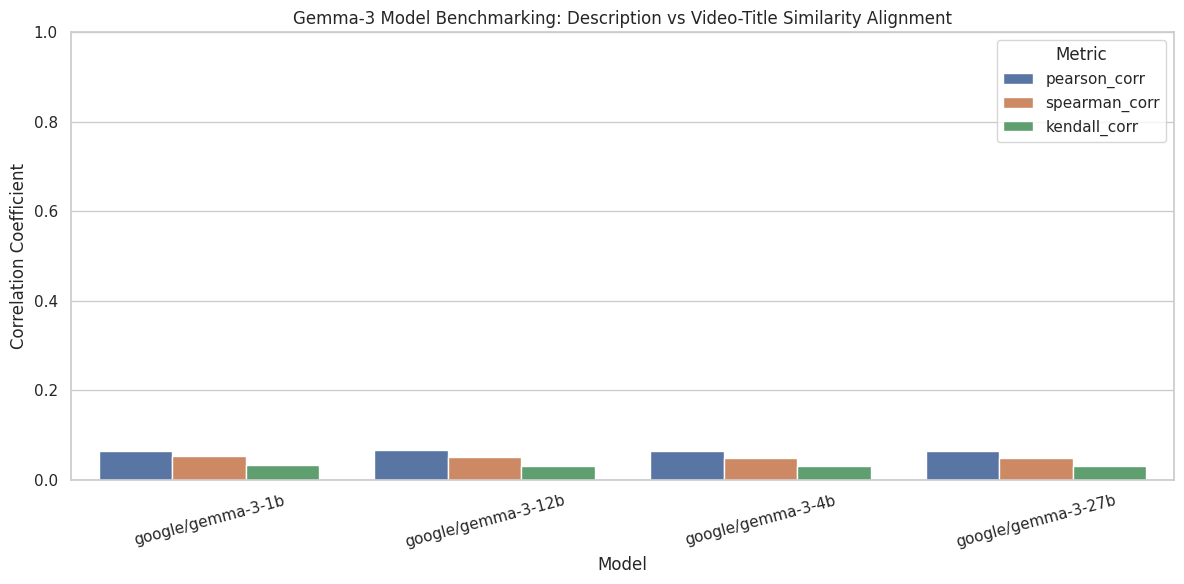

In [11]:
metrics = ['pearson_corr', 'spearman_corr', 'kendall_corr']
df_melted = benchmark_df.melt(id_vars='model', value_vars=metrics, var_name='metric', value_name='correlation')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='model', y='correlation', hue='metric')
plt.title('Gemma-3 Model Benchmarking: Description vs Video-Title Similarity Alignment')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.legend(title='Metric')
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(BENCHMARK_OUTPUT_DIR / 'gemma3_benchmark_comparison.png', dpi=160)
plt.show()